In [4]:
import time
import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from affine import Affine
from matplotlib.colors import ListedColormap
from rasterio.features import shapes
from segment_anything import SamAutomaticMaskGenerator, SamPredictor, sam_model_registry
from shapely.geometry import shape
from shapely.ops import unary_union

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

SCIEZKA_ZDJECIA = Path("data/tapias_ortofoto.tif")   # <- tu podstaw własne zdjęcie
KATALOG_WYNIKOW = Path("results")
KATALOG_MODELI = Path("modele")
KATALOG_WYNIKOW.mkdir(exist_ok=True)

TYP_MODELU = "vit_b"    # vit_b (375 MB, najszybszy) | vit_l (1,2 GB) | vit_h (2,6 GB, najdokładniejszy)
WAGI = {"vit_b": "sam_vit_b_01ec64.pth", "vit_l": "sam_vit_l_0b3195.pth", "vit_h": "sam_vit_h_4b8939.pth"}
URL_WAG = "https://dl.fbaipublicfiles.com/segment_anything/"

# Generator automatycznych masek używa liczb float64, których nie obsługuje GPU w Macach (MPS) — tam zostajemy przy CPU.
URZADZENIE = "cuda" if torch.cuda.is_available() else "cpu"

# Kadr do klikania i powiększeń (wiersze, kolumny) — ten sam co w poziomie 1 — oraz jego położenie w całym zdjęciu
FRAGMENT = np.s_[850:1250, 1000:1400]
Y0, X0 = FRAGMENT[0].start, FRAGMENT[1].start

Zdjęcie: 1731 x 1731 px, GSD 0.12 m, układ EPSG:32618
Po skalowaniu do 1024 px:  piksel = 20 cm (pomniejszenie 1.7x)
Kadr 400 x 400 px:  piksel = 4.7 cm (powiększenie 2.6x)


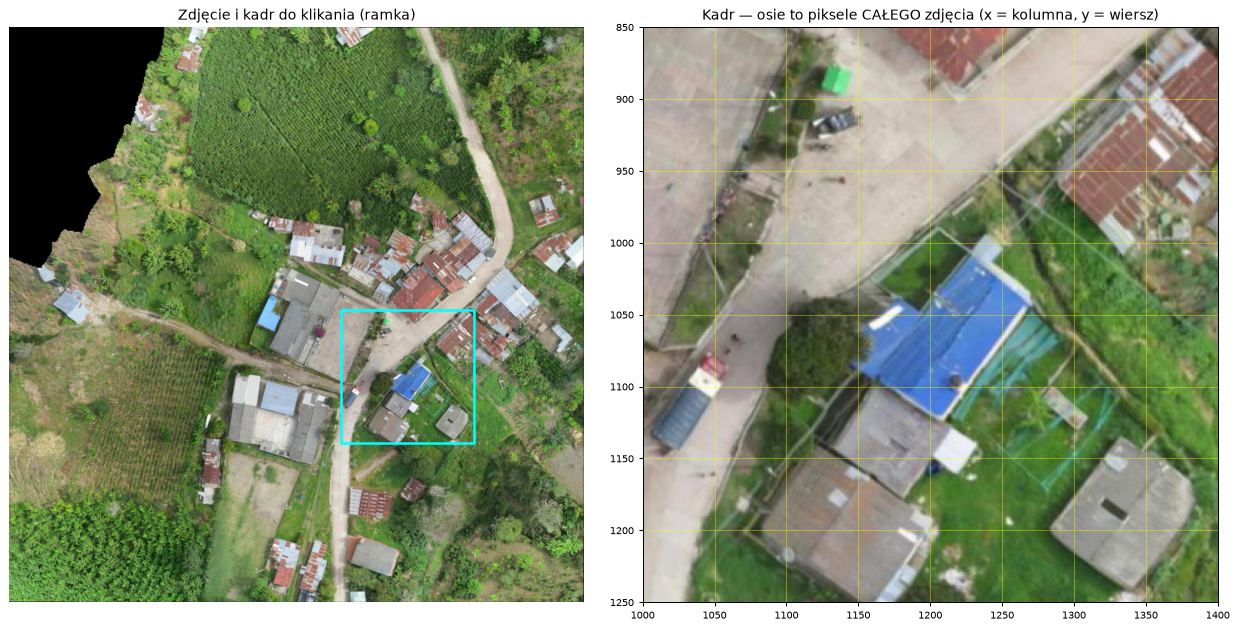

In [5]:
def wczytaj_zdjecie(sciezka, gsd_reczne=None):
    """Zwraca: rgb (H,W,3 uint8), waznie (H,W bool), profil (transform, crs), gsd [m/piksel]."""
    with rasterio.open(sciezka) as src:
        if src.count < 3 or src.dtypes[0] != "uint8":
            raise ValueError(f"Oczekuję 8-bitowego RGB, a jest: {src.count} pasm, {src.dtypes[0]}")
        rgb = np.moveaxis(src.read([1, 2, 3]), 0, -1)
        profil = {"transform": src.transform, "crs": src.crs}
        metryczny = src.crs is not None and src.crs.is_projected
        gsd = src.res[0] if metryczny else gsd_reczne
    waznie = ~(rgb == 0).all(axis=-1)          # czarne tło ortomozaiku = brak danych
    if gsd is None:
        raise ValueError("Zdjęcie nie jest w układzie metrycznym — podaj gsd_reczne (m/piksel).")
    return rgb, waznie, profil, gsd


def nakladka(rgb, maska, kolor=(255, 0, 255), alfa=0.55):
    """Półprzezroczysta maska nałożona na zdjęcie (do oceny wzrokowej)."""
    wynik = rgb.astype(np.float32)
    wynik[maska] = (1 - alfa) * wynik[maska] + alfa * np.array(kolor, dtype=np.float32)
    return wynik.astype(np.uint8)


rgb, waznie, profil, gsd = wczytaj_zdjecie(SCIEZKA_ZDJECIA)
kadr = rgb[FRAGMENT].copy()                                         # kadr jako osobna tablica (H, W, 3)
KADR_EXTENT = (X0, X0 + kadr.shape[1], Y0 + kadr.shape[0], Y0)      # osie wykresów = piksele CAŁEGO zdjęcia

print(f"Zdjęcie: {rgb.shape[1]} x {rgb.shape[0]} px, GSD {gsd:.2f} m, układ {profil['crs']}")
print(f"Po skalowaniu do 1024 px:  piksel = {gsd * max(rgb.shape[:2]) / 1024 * 100:.0f} cm "
      f"(pomniejszenie {max(rgb.shape[:2]) / 1024:.1f}x)")
print(f"Kadr {kadr.shape[1]} x {kadr.shape[0]} px:  piksel = {gsd * max(kadr.shape[:2]) / 1024 * 100:.1f} cm "
      f"(powiększenie {1024 / max(kadr.shape[:2]):.1f}x)")

fig, ax = plt.subplots(1, 2, figsize=(14, 6.8))
ax[0].imshow(rgb)
ax[0].add_patch(plt.Rectangle((X0, Y0), kadr.shape[1], kadr.shape[0], fill=False, ec="cyan", lw=2))
ax[0].set_title("Zdjęcie i kadr do klikania (ramka)"); ax[0].axis("off")
ax[1].imshow(kadr, extent=KADR_EXTENT)
ax[1].set_xticks(range(X0, X0 + 401, 50)); ax[1].set_yticks(range(Y0, Y0 + 401, 50))
ax[1].grid(color="yellow", alpha=0.5, lw=0.6); ax[1].tick_params(labelsize=8)
ax[1].set_title("Kadr — osie to piksele CAŁEGO zdjęcia (x = kolumna, y = wiersz)")
plt.tight_layout()

In [6]:
def pobierz_wagi(typ):
    plik = KATALOG_MODELI / WAGI[typ]
    if not plik.exists():
        KATALOG_MODELI.mkdir(exist_ok=True)
        print(f"Pobieram {plik.name} (jednorazowo)...")
        czesciowy = plik.with_suffix(".part")            # przerwane pobieranie nie zostawi uszkodzonego pliku z wagami
        urllib.request.urlretrieve(URL_WAG + plik.name, czesciowy)
        czesciowy.replace(plik)
    return plik


sam = sam_model_registry[TYP_MODELU](checkpoint=pobierz_wagi(TYP_MODELU)).to(URZADZENIE)

liczba_parametrow = lambda modul: sum(p.numel() for p in modul.parameters())
print(f"SAM {TYP_MODELU} na urządzeniu: {URZADZENIE}")
pd.Series({
    "koder obrazu (ViT)": liczba_parametrow(sam.image_encoder),
    "koder promptów": liczba_parametrow(sam.prompt_encoder),
    "dekoder masek": liczba_parametrow(sam.mask_decoder),
}, name="parametry").map(lambda n: f"{n / 1e6:.2f} mln")

Pobieram sam_vit_b_01ec64.pth (jednorazowo)...
SAM vit_b na urządzeniu: cpu


koder obrazu (ViT)    89.67 mln
koder promptów         0.01 mln
dekoder masek          4.06 mln
Name: parametry, dtype: str

In [7]:
predictor = SamPredictor(sam)

t0 = time.perf_counter()
predictor.set_image(kadr)                                            # ciężki krok: koder obrazu
print(f"set_image (koder obrazu):  {time.perf_counter() - t0:.2f} s")


def segmentuj_punkty(punkty, etykiety=None, wiele_masek=False):
    """punkty: lista (x, y) w pikselach CAŁEGO zdjęcia; etykiety: 1 = obiekt, 0 = nie-obiekt (domyślnie same jedynki).
    Zwraca maski (N, H, W bool — w układzie kadru) i przewidywaną przez SAM jakość każdej z nich (score)."""
    punkty = np.asarray(punkty, dtype=np.float32) - [X0, Y0]           # układ całego zdjęcia -> układ kadru
    etykiety = np.ones(len(punkty), dtype=int) if etykiety is None else np.asarray(etykiety)
    maski, jakosci, _ = predictor.predict(point_coords=punkty, point_labels=etykiety, multimask_output=wiele_masek)
    return maski, jakosci


t0 = time.perf_counter()
maski, jakosci = segmentuj_punkty([(1210, 1075)], wiele_masek=True)
print(f"predict (dekoder masek):   {(time.perf_counter() - t0) * 1000:.0f} ms  -> {len(maski)} maski, każda {maski.shape[1]} x {maski.shape[2]} px")

set_image (koder obrazu):  0.94 s
predict (dekoder masek):   15 ms  -> 3 maski, każda 400 x 400 px


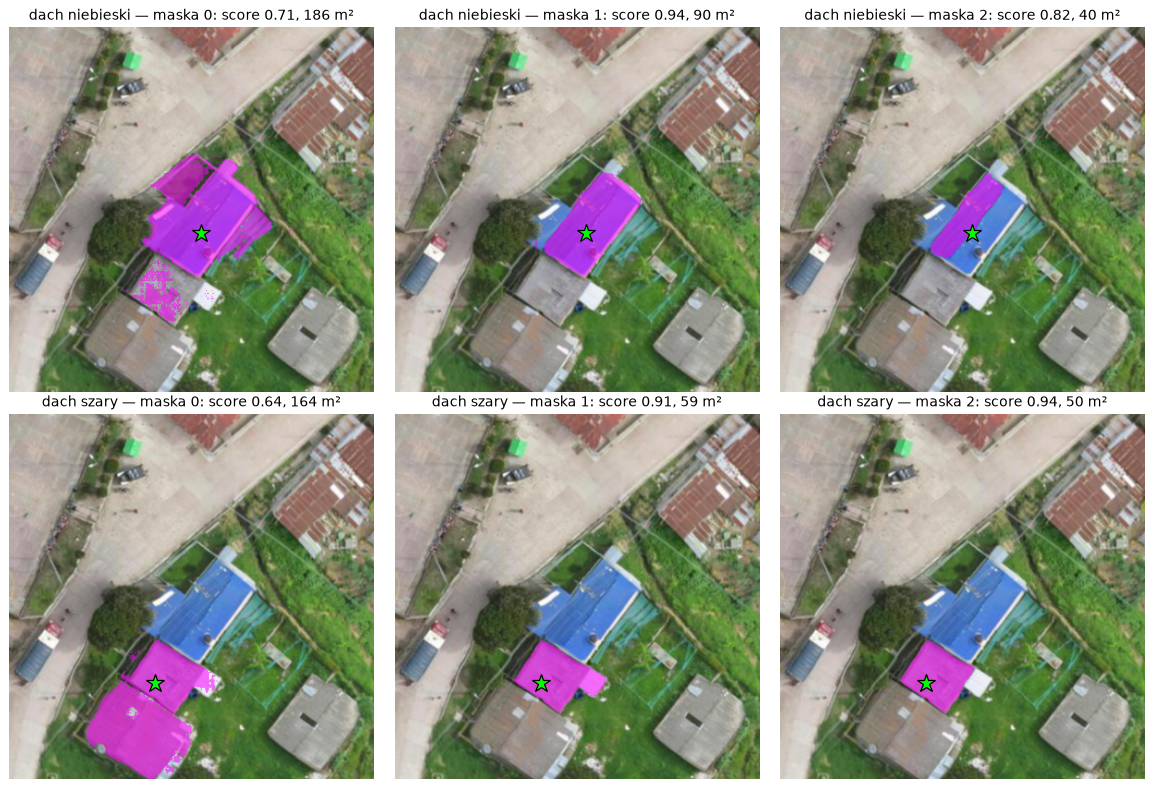

In [8]:
def pokaz_maski(ax, obraz, maska, punkty=(), etykiety=(), tytul=""):
    """Maska na kadrze (osie = piksele całego zdjęcia); punkty: zielona gwiazdka = pozytywny, czerwona = negatywny."""
    ax.imshow(nakladka(obraz, maska), extent=KADR_EXTENT)
    for (x, y), e in zip(punkty, etykiety):
        ax.plot(x, y, "*", ms=15, mec="k", color="lime" if e else "red")
    ax.set_title(tytul); ax.axis("off")


PRZYKLADY = {"dach niebieski": (1210, 1075), "dach szary": (1160, 1145)}

fig, ax = plt.subplots(len(PRZYKLADY), 3, figsize=(13, 4.4 * len(PRZYKLADY)))
for w, (nazwa, punkt) in enumerate(PRZYKLADY.items()):
    maski, jakosci = segmentuj_punkty([punkt], wiele_masek=True)
    for k in range(3):
        pokaz_maski(ax[w, k], kadr, maski[k], [punkt], [1],
                    f"{nazwa} — maska {k}: score {jakosci[k]:.2f}, {maski[k].sum() * gsd ** 2:.0f} m²")
plt.tight_layout()

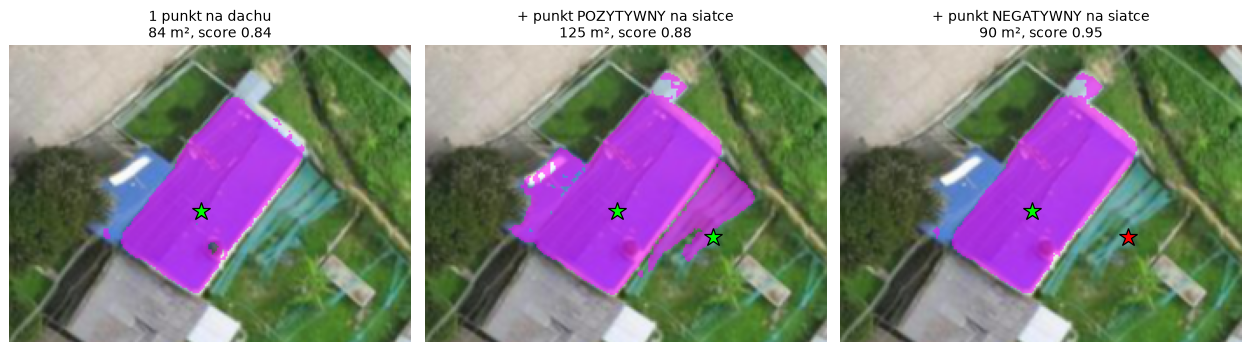

In [9]:
DACH = (1210, 1075)       # niebieski dach
SIATKA = (1265, 1090)     # zielona siatka (szklarnia) tuż obok

warianty = [
    ("1 punkt na dachu",             [DACH],         [1]),
    ("+ punkt POZYTYWNY na siatce",  [DACH, SIATKA], [1, 1]),
    ("+ punkt NEGATYWNY na siatce",  [DACH, SIATKA], [1, 0]),
]

fig, ax = plt.subplots(1, 3, figsize=(14, 4.8))
for a, (opis, punkty, etykiety) in zip(ax, warianty):
    maski, jakosci = segmentuj_punkty(punkty, etykiety)
    pokaz_maski(a, kadr, maski[0], punkty, etykiety, f"{opis}\n{maski[0].sum() * gsd ** 2:.0f} m², score {jakosci[0]:.2f}")
    a.set_xlim(1100, 1330); a.set_ylim(1150, 980)                     # przybliżenie na dach
plt.tight_layout()

,nazwa,pow_m2,score
0,dach niebieski,90.0,0.86
1,drzewo,49.0,0.96
2,dach szary 1,88.5,0.91
3,dach szary 2,105.9,0.93


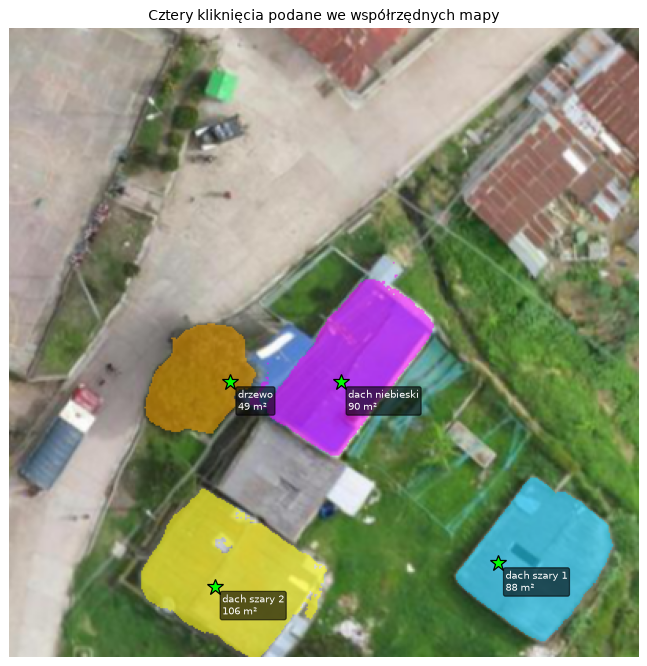

In [10]:
KLIKNIECIA_MAPY = {                # współrzędne (E, N) w EPSG:32618 — np. odczytane w QGIS-ie
    "dach niebieski": (461123.2, 492317.1),
    "drzewo":         (461114.8, 492317.1),
    "dach szary 1":   (461135.2, 492303.3),
    "dach szary 2":   (461113.6, 492301.5),
}
KOLORY = [(255, 0, 255), (255, 165, 0), (0, 200, 255), (255, 255, 0)]


def mapa_na_piksele(x, y):
    kolumna, wiersz = ~profil["transform"] * (x, y)
    return kolumna, wiersz


def maska_do_poligonu(maska, transform, gsd):
    """Maska (bool) -> jeden poligon (lub multipoligon) w układzie mapy, uproszczony o 1 piksel.
    `transform` musi opisywać położenie samej tablicy `maska` (nie całego zdjęcia)."""
    czesci = [shape(g) for g, _ in shapes(maska.astype(np.uint8), mask=maska, transform=transform)]
    return unary_union(czesci).simplify(gsd)


transform_kadru = profil["transform"] * Affine.translation(X0, Y0)    # transformacja liczona od lewego górnego rogu kadru

wiersze, punkty_px, podglad = [], [], kadr
for (nazwa, (e, n)), kolor in zip(KLIKNIECIA_MAPY.items(), KOLORY):
    kolumna, wiersz = mapa_na_piksele(e, n)
    maski, jakosci = segmentuj_punkty([(kolumna, wiersz)])
    podglad = nakladka(podglad, maski[0], kolor)
    punkty_px.append((kolumna, wiersz))
    wiersze.append({"nazwa": nazwa, "pow_m2": round(float(maski[0].sum() * gsd ** 2), 1), "score": round(float(jakosci[0]), 2),
                    "geometry": maska_do_poligonu(maski[0], transform_kadru, gsd)})
klikniete = gpd.GeoDataFrame(wiersze, geometry="geometry", crs=profil["crs"])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(podglad, extent=KADR_EXTENT)
for (kolumna, wiersz), w in zip(punkty_px, wiersze):
    ax.plot(kolumna, wiersz, "*", ms=13, mec="k", color="lime")
    ax.annotate(f"{w['nazwa']}\n{w['pow_m2']:.0f} m²", (kolumna, wiersz), xytext=(6, -22), textcoords="offset points",
                fontsize=8, color="white", bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6))
ax.set_title("Cztery kliknięcia podane we współrzędnych mapy"); ax.axis("off")
plt.tight_layout()

klikniete[["nazwa", "pow_m2", "score"]]

In [11]:
def nowy_generator(punkty_na_bok=32, **parametry):
    """Automatyczny generator masek SAM (parametry — w tabeli powyżej). Maski mniejsze niż 100 px odsiewamy od razu."""
    return SamAutomaticMaskGenerator(sam, points_per_side=punkty_na_bok, min_mask_region_area=100, **parametry)


def obiekty_z_sam(maski_sam, wiersz0=0, kolumna0=0):
    """Słowniki SAM-a -> obiekty: maska przycięta do ramki + (wiersz, kolumna) jej lewego górnego rogu w całym zdjęciu.
    (wiersz0, kolumna0) to położenie obrazu podanego SAM-owi w całym zdjęciu (dla kadru lub kafla)."""
    obiekty = []
    for d in maski_sam:
        x, y, szer, wys = (int(round(v)) for v in d["bbox"])     # bbox SAM-a to (x, y, x_max − x_min, y_max − y_min): ramka ma o 1 px więcej
        obiekty.append({"maska": d["segmentation"][y:y + wys + 1, x:x + szer + 1].copy(),
                        "wiersz": wiersz0 + y, "kolumna": kolumna0 + x,
                        "piksele": int(d["area"]), "iou": float(d["predicted_iou"]), "stabilnosc": float(d["stability_score"])})
    return obiekty


def czesc_wazna(obiekt, waznie):
    """Jaka część pikseli obiektu leży na ważnych danych (a nie na czarnym tle ortomozaiku)."""
    wys, szer = obiekt["maska"].shape
    return waznie[obiekt["wiersz"]:obiekt["wiersz"] + wys, obiekt["kolumna"]:obiekt["kolumna"] + szer][obiekt["maska"]].mean()


def koloruj_obiekty(obraz, obiekty, alfa=0.6, seed=1):
    """Każdy obiekt w innym losowym kolorze. Większe maluje pierwsze, mniejsze na wierzchu — bo maski się nakładają."""
    rng = np.random.default_rng(seed)
    wynik = obraz.astype(np.float32)
    for o in sorted(obiekty, key=lambda o: -o["piksele"]):
        wys, szer = o["maska"].shape
        okno = wynik[o["wiersz"]:o["wiersz"] + wys, o["kolumna"]:o["kolumna"] + szer]
        okno[o["maska"]] = (1 - alfa) * okno[o["maska"]] + alfa * rng.integers(40, 255, 3)
    return wynik.astype(np.uint8)

,area,bbox,predicted_iou,point_coords,stability_score,crop_box
0,6185,"[284, 286, 99, 103]",0.993790,"[[343.75, 331.25]]",0.976811,"[0, 0, 400, 400]"
1,584,"[201, 279, 31, 31]",0.981095,"[[218.75, 306.25]]",0.974403,"[0, 0, 400, 400]"
2,432,"[279, 250, 30, 29]",0.979756,"[[293.75, 268.75]]",0.981651,"[0, 0, 400, 400]"
3,3430,"[86, 188, 70, 70]",0.974967,"[[143.75, 231.25]]",0.966437,"[0, 0, 400, 400]"
4,379,"[317, 129, 25, 29]",0.974197,"[[331.25, 143.75]]",0.976623,"[0, 0, 400, 400]"


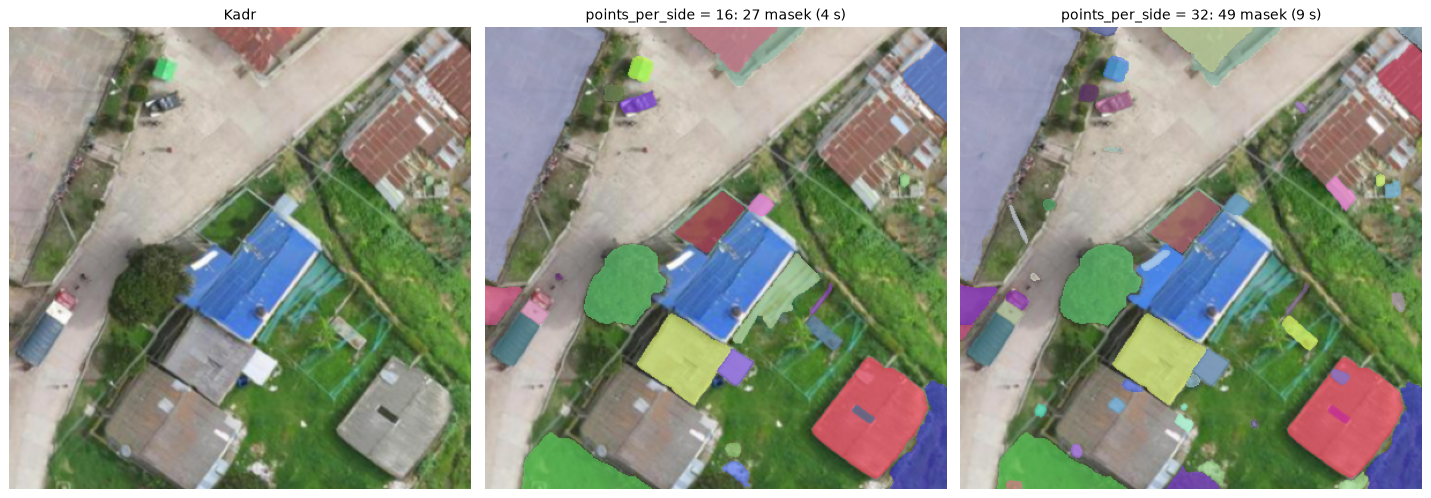

In [12]:
wyniki_kadru = {}
fig, ax = plt.subplots(1, 3, figsize=(16, 5.6))
ax[0].imshow(kadr); ax[0].set_title("Kadr")
for a, pps in zip(ax[1:], (16, 32)):
    t0 = time.perf_counter()
    wyniki_kadru[pps] = nowy_generator(pps).generate(kadr)
    czas = time.perf_counter() - t0
    a.imshow(koloruj_obiekty(kadr, obiekty_z_sam(wyniki_kadru[pps])))
    a.set_title(f"points_per_side = {pps}: {len(wyniki_kadru[pps])} masek ({czas:.0f} s)")
for a in ax: a.axis("off")
plt.tight_layout()

pd.DataFrame(wyniki_kadru[32]).drop(columns="segmentation").head()      # „segmentation" to pełna maska (H, W, bool)

Masek: 129, czas: 14 s, pamięć na pełnowymiarowe maski: 387 MB
Masek leżących na czarnym tle poza mozaiką: 1


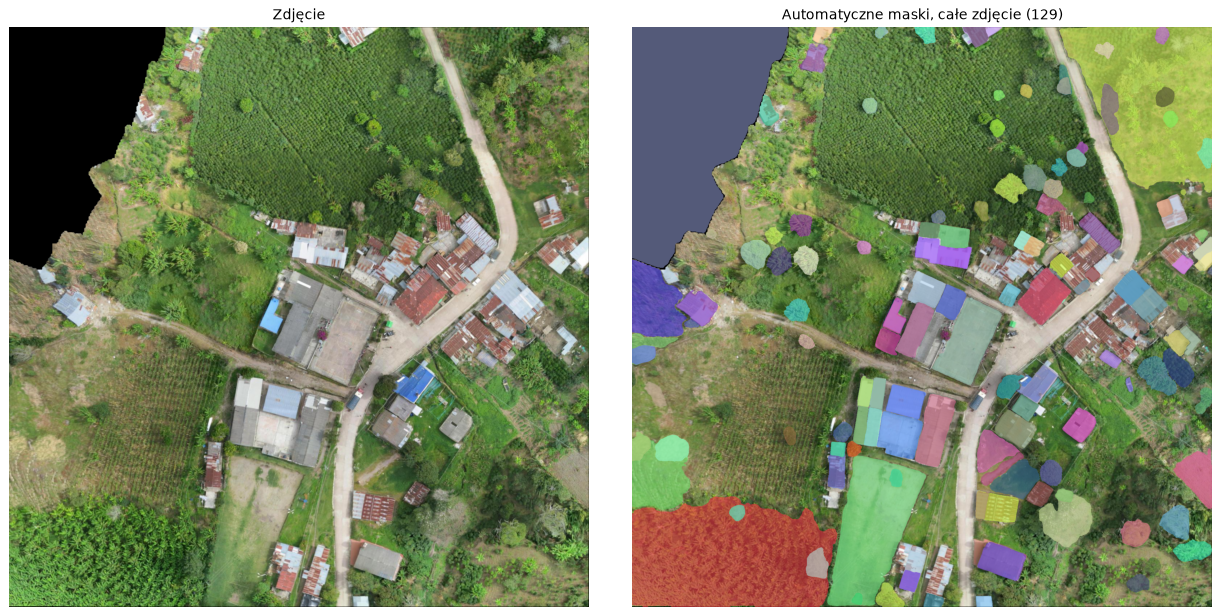

In [13]:
t0 = time.perf_counter()
maski_cale = nowy_generator(32).generate(rgb)
czas_cale = time.perf_counter() - t0
obiekty_cale = obiekty_z_sam(maski_cale)

na_tle = sum(czesc_wazna(o, waznie) < 0.5 for o in obiekty_cale)
pamiec_mb = sum(d["segmentation"].nbytes for d in maski_cale) / 1e6
print(f"Masek: {len(maski_cale)}, czas: {czas_cale:.0f} s, pamięć na pełnowymiarowe maski: {pamiec_mb:.0f} MB")
print(f"Masek leżących na czarnym tle poza mozaiką: {na_tle}")

fig, ax = plt.subplots(1, 2, figsize=(14, 6.8))
ax[0].imshow(rgb); ax[0].set_title("Zdjęcie")
ax[1].imshow(koloruj_obiekty(rgb, obiekty_cale)); ax[1].set_title(f"Automatyczne maski, całe zdjęcie ({len(maski_cale)})")
for a in ax: a.axis("off")
plt.tight_layout()

Masek: 54, czas: 4 s, pamięć na pełnowymiarowe maski: 162 MB
Masek leżących na czarnym tle poza mozaiką: 1


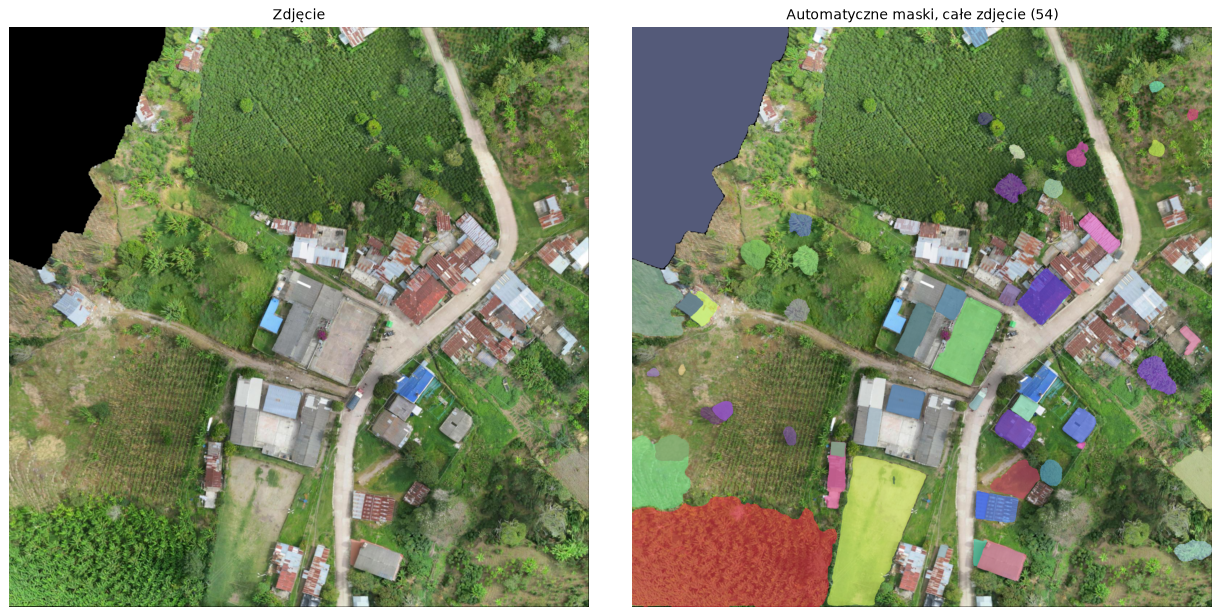

In [15]:
t0 = time.perf_counter()
maski_cale = nowy_generator(16).generate(rgb)
czas_cale = time.perf_counter() - t0
obiekty_cale = obiekty_z_sam(maski_cale)

na_tle = sum(czesc_wazna(o, waznie) < 0.5 for o in obiekty_cale)
pamiec_mb = sum(d["segmentation"].nbytes for d in maski_cale) / 1e6
print(f"Masek: {len(maski_cale)}, czas: {czas_cale:.0f} s, pamięć na pełnowymiarowe maski: {pamiec_mb:.0f} MB")
print(f"Masek leżących na czarnym tle poza mozaiką: {na_tle}")

fig, ax = plt.subplots(1, 2, figsize=(14, 6.8))
ax[0].imshow(rgb); ax[0].set_title("Zdjęcie")
ax[1].imshow(koloruj_obiekty(rgb, obiekty_cale)); ax[1].set_title(f"Automatyczne maski, całe zdjęcie ({len(maski_cale)})")
for a in ax: a.axis("off")
plt.tight_layout()

In [17]:
def poczatki_kafli(n, kafel, zakladka):
    """Początki kafli o boku `kafel` px, równomiernie pokrywających `n` px, z zakładką nie mniejszą niż `zakladka`."""
    if n <= kafel:
        return [0]
    liczba = int(np.ceil((n - zakladka) / (kafel - zakladka)))
    return np.linspace(0, n - kafel, liczba).round().astype(int).tolist()


def iou_obiektow(a, b):
    """IoU dwóch obiektów zapisanych jako przycięte maski z położeniem (bez budowania pełnowymiarowych masek)."""
    w0, k0 = max(a["wiersz"], b["wiersz"]), max(a["kolumna"], b["kolumna"])
    w1 = min(a["wiersz"] + a["maska"].shape[0], b["wiersz"] + b["maska"].shape[0])
    k1 = min(a["kolumna"] + a["maska"].shape[1], b["kolumna"] + b["maska"].shape[1])
    if w1 <= w0 or k1 <= k0:
        return 0.0
    ma = a["maska"][w0 - a["wiersz"]:w1 - a["wiersz"], k0 - a["kolumna"]:k1 - a["kolumna"]]
    mb = b["maska"][w0 - b["wiersz"]:w1 - b["wiersz"], k0 - b["kolumna"]:k1 - b["kolumna"]]
    wspolna = (ma & mb).sum()
    return wspolna / (a["piksele"] + b["piksele"] - wspolna)


def maski_kafelkami(rgb, waznie, generator, gsd, kafel_m=77, zakladka_m=15, min_obiekt_m2=2.0):
    """SAM na kafelkach z zakładką. Zwraca listę obiektów (przycięta maska + położenie w całym zdjęciu)."""
    wys_zdj, szer_zdj = waznie.shape
    kafel, zakladka = round(kafel_m / gsd), round(zakladka_m / gsd)
    kandydaci = []
    for w0 in poczatki_kafli(wys_zdj, kafel, zakladka):
        for k0 in poczatki_kafli(szer_zdj, kafel, zakladka):
            okno = np.s_[w0:w0 + kafel, k0:k0 + kafel]
            if waznie[okno].mean() < 0.05:                       # kafel prawie bez danych
                continue
            wys, szer = waznie[okno].shape
            for o in obiekty_z_sam(generator.generate(rgb[okno].copy()), w0, k0):
                h, w = o["maska"].shape
                y, x = o["wiersz"] - w0, o["kolumna"] - k0        # położenie maski w kaflu
                ucieta = ((x == 0 and k0 > 0) or (y == 0 and w0 > 0)                       # dotyka wewnętrznej krawędzi kafla
                          or (x + w == szer and k0 + szer < szer_zdj) or (y + h == wys and w0 + wys < wys_zdj))
                if not ucieta and czesc_wazna(o, waznie) >= 0.5 and o["piksele"] * gsd ** 2 >= min_obiekt_m2:
                    kandydaci.append(o)

    kandydaci.sort(key=lambda o: -o["iou"])                     # najpewniejsze pierwsze
    zostawione = []
    for o in kandydaci:
        if all(iou_obiektow(o, z) < 0.7 for z in zostawione):    # duplikat z zakładki?
            zostawione.append(o)
    return zostawione

In [ ]:
t0 = time.perf_counter()
obiekty_kafle = maski_kafelkami(rgb, waznie, nowy_generator(16), gsd)
czas_kafle = time.perf_counter() - t0

ZOOM = np.s_[600:1000, 1050:1450]                                 # zwarta zabudowa przy drodze
podglad_cale, podglad_kafle = koloruj_obiekty(rgb, obiekty_cale), koloruj_obiekty(rgb, obiekty_kafle)

fig, ax = plt.subplots(2, 2, figsize=(11.5, 11.5))
ax[0, 0].imshow(podglad_cale); ax[0, 0].set_title(f"Całe zdjęcie: {len(obiekty_cale)} masek ({czas_cale:.0f} s)")
ax[0, 1].imshow(podglad_kafle); ax[0, 1].set_title(f"Kafle 77 m: {len(obiekty_kafle)} obiektów ({czas_kafle:.0f} s)")
ax[1, 0].imshow(podglad_cale[ZOOM]); ax[1, 0].set_title("Całe zdjęcie — powiększenie")
ax[1, 1].imshow(podglad_kafle[ZOOM]); ax[1, 1].set_title("Kafle — to samo powiększenie")
for a in ax.ravel(): a.axis("off")
plt.tight_layout()

pd.DataFrame({
    "całe zdjęcie": {"obiektów": len(obiekty_cale), "mediana [m²]": np.median([o["piksele"] for o in obiekty_cale]) * gsd ** 2,
                     "na czarnym tle": na_tle},
    "kafelki": {"obiektów": len(obiekty_kafle), "mediana [m²]": np.median([o["piksele"] for o in obiekty_kafle]) * gsd ** 2,
                "na czarnym tle": sum(czesc_wazna(o, waznie) < 0.5 for o in obiekty_kafle)},
}).round(1)

In [ ]:
def exg(rgb):
    """Excess Green z współrzędnych chromatycznych — jak w poziomie 1."""
    R, G, B = (rgb[..., i].astype(np.float32) for i in range(3))
    suma = R + G + B + 1e-6
    return 2 * G / suma - R / suma - B / suma


PROG_EXG = 0.10      # obiekt jest „zielony", gdy jego średni ExG jest wyższy (ta sama reguła co dla klastrów w poziomie 1)


def obiekty_do_gdf(obiekty, rgb, profil, gsd):
    """Obiekty SAM-a -> GeoDataFrame: poligon w układzie zdjęcia + atrybuty."""
    mapa_exg = exg(rgb)
    wiersze = []
    for i, o in enumerate(obiekty, start=1):
        wys, szer = o["maska"].shape
        exg_sr = float(mapa_exg[o["wiersz"]:o["wiersz"] + wys, o["kolumna"]:o["kolumna"] + szer][o["maska"]].mean())
        geometria = maska_do_poligonu(o["maska"], profil["transform"] * Affine.translation(o["kolumna"], o["wiersz"]), gsd)
        wiersze.append({
            "id": i,
            "pow_m2": round(o["piksele"] * gsd ** 2, 1),
            "zwartosc": round(4 * np.pi * geometria.area / geometria.length ** 2, 2),
            "exg_sr": round(exg_sr, 3),
            "zielone": exg_sr > PROG_EXG,
            "sam_iou": round(o["iou"], 2),
            "sam_stabilnosc": round(o["stabilnosc"], 2),
            "geometry": geometria,
        })
    return gpd.GeoDataFrame(wiersze, geometry="geometry", crs=profil["crs"])


obiekty_gdf = obiekty_do_gdf(obiekty_kafle, rgb, profil, gsd)
print(f"Obiektów: {len(obiekty_gdf)}, w tym „zielonych”: {obiekty_gdf.zielone.sum()}")

lewo, gora = profil["transform"] * (0, 0)
prawo, dol = profil["transform"] * (rgb.shape[1], rgb.shape[0])
fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.25, 1]})
ax[0].imshow(rgb, extent=(lewo, prawo, dol, gora))
obiekty_gdf.sort_values("pow_m2", ascending=False).plot(          # duże pierwsze, małe na wierzchu
    ax=ax[0], column="zielone", categorical=True, cmap=ListedColormap(["orange", "limegreen"]),
    alpha=0.5, edgecolor="k", linewidth=0.3)
ax[0].set_title("Obiekty SAM-a: zielony = ExG > 0,10, pomarańczowy = reszta"); ax[0].set_axis_off()
ax[1].hist([obiekty_gdf.pow_m2[obiekty_gdf.zielone], obiekty_gdf.pow_m2[~obiekty_gdf.zielone]], bins=np.logspace(0.3, 2.7, 25),
           stacked=True, color=["limegreen", "orange"], label=["zielone", "reszta"])
ax[1].set_xscale("log"); ax[1].set_xlabel("powierzchnia obiektu [m²]"); ax[1].set_ylabel("liczba obiektów")
ax[1].set_title("Rozkład powierzchni obiektów"); ax[1].legend()
plt.tight_layout()

obiekty_gdf.drop(columns="geometry").sort_values("pow_m2", ascending=False).head(8)

NameError: name 'obiekty_kafle' is not defined